# Checkpoint 6: Model Comparison and Error Analysis

This notebook is written in study mode so each step explains both implementation and supervised-learning reasoning.

Evaluation protocols used:
- Full-scope protocol: classic TF-IDF models and LSTM on the full test split
- Fair protocol: all models evaluated on the same selected test rows

Current default for fair protocol: full test size (7500 rows).
- This removes sample-size bias in model ranking.
- If runtime becomes a blocker, we can temporarily lower the transformer evaluation size and clearly label results as runtime-limited.

Models included:
- Classic TF-IDF models (Naive Bayes, Logistic Regression, Linear SVM, Random Forest)
- LSTM model from Checkpoint 5
- Pre-trained Transformer baseline from Hugging Face

Checkpoint 5 closure note: sequence preprocessing, LSTM training/evaluation, training curves, and saved artifacts were completed in Notebook 04.

## 1) Setup and imports

What we are doing:
- Import reusable modules and define helper utilities for metrics and sequence padding.

Why this matters for supervised learning:
- Consistent utility functions reduce accidental evaluation differences across models.
- Reproducible paths and constants make results auditable and repeatable.

What we are trying to learn:
- Whether our environment and helper functions are stable before model evaluation begins.

In [59]:
from __future__ import annotations

import importlib
import sys

from pathlib import Path

project_root = Path.cwd().resolve().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, f1_score, precision_score, recall_score, roc_curve
from tensorflow.keras.models import load_model
from transformers import pipeline
from src.config import FIGURES_DIR, PROJECT_ROOT, RAW_DATA_PATH, RESULTS_DIR
from src.data_loader import get_splits

def _import_pad_sequences():
    try:
        utils_module = importlib.import_module('keras.utils')
        return getattr(utils_module, 'pad_sequences')
    except (ModuleNotFoundError, ImportError, AttributeError):
        seq_module = importlib.import_module('tensorflow.keras.preprocessing.sequence')
        return getattr(seq_module, 'pad_sequences')


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

MODELS_DIR = PROJECT_ROOT / 'models'
METRICS_DIR = RESULTS_DIR / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pad_sequences = _import_pad_sequences()

RANDOM_SEED = 42
TRANSFORMER_SAMPLE_SIZE = 7500  # all test rows — no sub-sampling
BERT_RAW_SAMPLE = 1500          # rows used for the raw-text DistilBERT demonstration

# Consistent colour palette — one colour per metric, shared across every plot
PALETTE = {
    'accuracy':  '#2a9d8f',   # teal
    'f1':        '#e9c46a',   # gold
    'precision': '#457b9d',   # steel blue
    'recall':    '#e63946',   # crimson
}


## 2) Load data splits and saved artifacts

What we are doing:
- Load the exact train/validation/test split policy used earlier.
- Reload saved classic models, TF-IDF vectorizer, LSTM model, and tokenizer (no retraining).

Why this matters for supervised learning:
- Evaluation should test trained models, not retrain under potentially different randomness.
- Artifact reuse ensures this notebook is a true comparison stage, not another training stage.

What we are trying to learn:
- Whether all required artifacts are complete and compatible for a fair evaluation pipeline.

In [60]:
X_train_text, y_train, X_val_text, y_val, X_test_text, y_test = get_splits(verbose=True)

# Load classic feature transformer and models
vectorizer = load(MODELS_DIR / 'tfidf_vectorizer_classic_models.joblib')
classic_models = {
    'Naive Bayes (TF-IDF)': load(MODELS_DIR / 'naive_bayes.joblib'),
    'Logistic Regression (TF-IDF)': load(MODELS_DIR / 'logistic_regression_(tuned).joblib'),
    'Linear SVM (TF-IDF)': load(MODELS_DIR / 'linear_svm.joblib'),
    'Random Forest (TF-IDF)': load(MODELS_DIR / 'random_forest.joblib'),
}

# Load LSTM artifacts
tokenizer = load(MODELS_DIR / 'tokenizer_lstm.joblib')
lstm_model = load_model(MODELS_DIR / 'lstm_final.keras')

print('Loaded classic models:', list(classic_models.keys()))
print('Loaded LSTM artifacts: tokenizer_lstm.joblib + lstm_final.keras')

Loaded 50,000 rows from preprocessed IMDB dataset.
Split sizes:
  train: 34,999 (70%)
  val  :  7,501 (15%)
  test :  7,500 (15%)
Label distribution (positive class count):
  train: 17,500 / 34,999
  val  :  3,750 / 7,501
  test :  3,750 / 7,500
Loaded classic models: ['Naive Bayes (TF-IDF)', 'Logistic Regression (TF-IDF)', 'Linear SVM (TF-IDF)', 'Random Forest (TF-IDF)']
Loaded LSTM artifacts: tokenizer_lstm.joblib + lstm_final.keras


## 3) Generate predictions: classic models

What we are doing:
- Predict labels for each classic model on the shared TF-IDF test matrix.
- Store score signals (probability or decision score) for ROC analysis.

Why this matters for supervised learning:
- Label metrics (accuracy/F1) require predictions.
- Threshold-independent analysis (ROC/AUC) requires continuous scores.

What we are trying to learn:
- How each classic model performs under identical feature representation.

In [61]:
X_test_tfidf = vectorizer.transform(X_test_text)

y_test_np = np.asarray(y_test).reshape(-1).astype(int)
predictions = {}
scores = {}

for model_name, model in classic_models.items():
    y_pred = np.asarray(model.predict(X_test_tfidf)).reshape(-1).astype(int)
    predictions[model_name] = y_pred

    if hasattr(model, 'predict_proba'):
        model_scores = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        model_scores = model.decision_function(X_test_tfidf)
    else:
        model_scores = y_pred.astype(float)
    scores[model_name] = np.asarray(model_scores).reshape(-1)

print('Classic model predictions ready:', len(predictions))

Classic model predictions ready: 4


## 4) Generate predictions: LSTM

What we are doing:
- Convert text to integer sequences using the saved tokenizer.
- Pad/truncate sequences to model input length.
- Run inference with the saved LSTM and collect probabilities/predictions.

Why this matters for supervised learning:
- Sequence models require token-order-aware numeric input, unlike TF-IDF sparse vectors.
- Keeping the saved tokenizer/model pair preserves training-time semantics during evaluation.

What we are trying to learn:
- Whether sequence-based modeling yields measurable gains over classic sparse-feature baselines.

In [62]:
test_sequences = tokenizer.texts_to_sequences(X_test_text.tolist())

input_shape = getattr(lstm_model, 'input_shape', None)

if isinstance(input_shape, tuple) and len(input_shape) > 1 and input_shape[1] is not None:

    max_sequence_length = int(input_shape[1])

else:

    max_sequence_length = 300

X_test_dl = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post', truncating='post')



lstm_prob = lstm_model.predict(X_test_dl, verbose=0).reshape(-1)

lstm_pred = (lstm_prob >= 0.5).astype(int)



predictions['LSTM (Keras)'] = lstm_pred

scores['LSTM (Keras)'] = lstm_prob



print('LSTM test shape:', X_test_dl.shape)

print('LSTM predictions ready')


LSTM test shape: (7500, 300)
LSTM predictions ready


## 5) Pre-trained Transformer baseline

**Model:** `distilbert/distilbert-base-uncased-finetuned-sst-2-english`

Two evaluations are run in this cell:

1. **Preprocessed input (7,500 rows)** — the same stopword-removed, lemmatized text fed to all other models. Included in the main comparison table.
2. **Raw text input (1,500 rows)** — natural English reviews as written, loaded from `IMDB Dataset.csv` using the same test-split indices. This directly demonstrates the preprocessing mismatch: the score difference between conditions is caused by input format, not model capability.

**Why this matters:** DistilBERT was fine-tuned on natural English sentences (SST-2). Preprocessing turns `"The acting in this film is not good at all."` into `"act film not good"` — breaking the grammatical structure the model depends on.
Expected: preprocessed ≈ 77%, raw text ≈ 93–95%.


In [63]:
rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(TRANSFORMER_SAMPLE_SIZE, len(X_test_text))
sample_idx = np.arange(sample_size)

X_test_sample = X_test_text.iloc[sample_idx].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_idx].reset_index(drop=True).astype(int).to_numpy()

HF_MODEL_ID = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english'
hf_classifier = pipeline('sentiment-analysis', model=HF_MODEL_ID, device=-1)

# ── Evaluation 1: preprocessed text (same input as all other models) ──
print('Running DistilBERT on preprocessed text...')
hf_outputs = hf_classifier(X_test_sample.tolist(), truncation=True, max_length=512, batch_size=16)
hf_prob = np.array([
    out['score'] if 'POSITIVE' in out['label'].upper() else 1.0 - out['score']
    for out in hf_outputs
])
hf_pred = (hf_prob >= 0.5).astype(int)

predictions['Pre-trained Transformer (DistilBERT)'] = hf_pred
scores['Pre-trained Transformer (DistilBERT)'] = hf_prob

print(f'  Model: {HF_MODEL_ID}')
print(f'  Preprocessed-text evaluation size: {sample_size}')

# ── Evaluation 2: raw text (preprocessing mismatch demonstration) ──
# The raw and preprocessed CSVs have 50,000 rows in the same order.
# The same train_test_split(random_state=42, stratify=label) produces
# identical test indices for both datasets — verified by comparing index sets.
print(f'\nRunning DistilBERT on raw text ({BERT_RAW_SAMPLE} rows)...')
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df['_label'] = (raw_df['sentiment'] == 'positive').astype(int)
_, raw_test_df = train_test_split(
    raw_df, test_size=0.15, random_state=RANDOM_SEED, stratify=raw_df['_label']
)
X_test_raw = raw_test_df.reset_index(drop=True)['review']
y_test_raw = raw_test_df.reset_index(drop=True)['_label'].to_numpy()

hf_outputs_raw = hf_classifier(
    X_test_raw[:BERT_RAW_SAMPLE].tolist(), truncation=True, max_length=512, batch_size=16
)
hf_prob_raw = np.array([
    out['score'] if 'POSITIVE' in out['label'].upper() else 1.0 - out['score']
    for out in hf_outputs_raw
])
hf_pred_raw = (hf_prob_raw >= 0.5).astype(int)

raw_m = compute_metrics(y_test_raw[:BERT_RAW_SAMPLE],    hf_pred_raw)
pre_m = compute_metrics(y_test_sample[:BERT_RAW_SAMPLE], hf_pred[:BERT_RAW_SAMPLE])

print(f'\n── Preprocessing mismatch demonstration (same {BERT_RAW_SAMPLE} test rows) ──')
print(f"  Preprocessed input:  accuracy={pre_m['accuracy']:.3f}  F1={pre_m['f1']:.3f}  "
      f"precision={pre_m['precision']:.3f}  recall={pre_m['recall']:.3f}")
print(f"  Raw text input:      accuracy={raw_m['accuracy']:.3f}  F1={raw_m['f1']:.3f}  "
      f"precision={raw_m['precision']:.3f}  recall={raw_m['recall']:.3f}")
print(f"  Accuracy gap:  {raw_m['accuracy'] - pre_m['accuracy']:+.3f}  "
      f"(caused entirely by input format, not model capability)")


c:\projects\imdb-sentiment-analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
All PyTorch model weights were used when initializing TFDistilBertForSequenceClassification.

All the weights of TFDistilBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


Running DistilBERT on preprocessed text...
  Model: distilbert/distilbert-base-uncased-finetuned-sst-2-english
  Preprocessed-text evaluation size: 7500

Running DistilBERT on raw text (1500 rows)...

── Preprocessing mismatch demonstration (same 1500 test rows) ──
  Preprocessed input:  accuracy=0.793  F1=0.737  precision=0.928  recall=0.612
  Raw text input:      accuracy=0.902  F1=0.894  precision=0.919  recall=0.871
  Accuracy gap:  +0.109  (caused entirely by input format, not model capability)


## 6) Build common evaluation set

All six models are evaluated on the same 7,500 test rows.
Classic model and LSTM predictions are aliased here into `predictions_common`
and `scores_common` so all downstream cells use a single consistent interface.


In [64]:
# All models evaluated on the same 7,500 rows — no sub-sampling.
# Alias into common-sample variables for downstream compatibility.
y_test_common = y_test_sample  # same as y_test_np (7,500 rows)

predictions_common = {}
scores_common = {}

model_keys = list(classic_models.keys()) + ['LSTM (Keras)', 'Pre-trained Transformer (DistilBERT)']
for model_name in model_keys:
    predictions_common[model_name] = predictions[model_name]
    scores_common[model_name] = scores[model_name]

print(f'Common-sample predictions ready for all models: {len(predictions_common)}')
print(f'Common sample size: {len(y_test_common)}')


Common-sample predictions ready for all models: 6
Common sample size: 7500


## 7) Build comparison table

All six models on the same 7,500 test rows — single fair-protocol table, sorted by F1.


In [65]:
training_time_note = {
    'Naive Bayes (TF-IDF)':                 'Seconds',
    'Logistic Regression (TF-IDF)':         'Seconds–minutes',
    'Linear SVM (TF-IDF)':                  'Minutes',
    'Random Forest (TF-IDF)':              'Minutes (high among classic)',
    'LSTM (Keras)':                         'High — epoch-based training (~17 min/epoch on CPU)',
    'Pre-trained Transformer (DistilBERT)': 'Inference only (no task training)',
}

rows = []
for model_name, y_pred in predictions_common.items():
    metric_values = compute_metrics(y_test_common, np.asarray(y_pred).reshape(-1).astype(int))
    rows.append({
        'model': model_name,
        'evaluated_on': f'test_{len(y_test_common)}_rows',
        **metric_values,
        'training_time_note': training_time_note.get(model_name, '—'),
    })

comparison_df = pd.DataFrame(rows).sort_values(by='f1', ascending=False).reset_index(drop=True)

comparison_path = METRICS_DIR / 'model_comparison_metrics.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'Saved -> {comparison_path}')

comparison_df


Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\model_comparison_metrics.csv


,model,evaluated_on,accuracy,precision,recall,f1,training_time_note
0,Logistic Regression (TF-IDF),test_7500_rows,0.891867,0.882384,0.904267,0.893191,Seconds–minutes
1,Linear SVM (TF-IDF),test_7500_rows,0.886933,0.882648,0.892533,0.887563,Minutes
2,LSTM (Keras),test_7500_rows,0.872800,0.871809,0.874133,0.872969,High — epoch-based training (~17 min/epoch on ...
3,Naive Bayes (TF-IDF),test_7500_rows,0.868933,0.855199,0.888267,0.871419,Seconds
4,Random Forest (TF-IDF),test_7500_rows,0.855867,0.857871,0.853067,0.855462,Minutes (high among classic)
5,Pre-trained Transformer (DistilBERT),test_7500_rows,0.774133,0.920622,0.600000,0.726510,Inference only (no task training)


## 8) Visual comparisons (fair protocol)

What we are doing:
- Plot accuracy/F1 bars, ROC curves, and complexity-vs-accuracy scatter using the fair protocol outputs.

Why this matters for supervised learning:
- Supervised classification quality should be examined from multiple angles, not a single metric.
- ROC/AUC adds threshold-independent view beyond one classification threshold.

How to interpret each figure:
- Accuracy/F1 bars: direct ranking under current thresholding.
- ROC curves: class separability across all thresholds (higher and more left is better).
- Complexity vs Accuracy: practical trade-off between performance and cost.

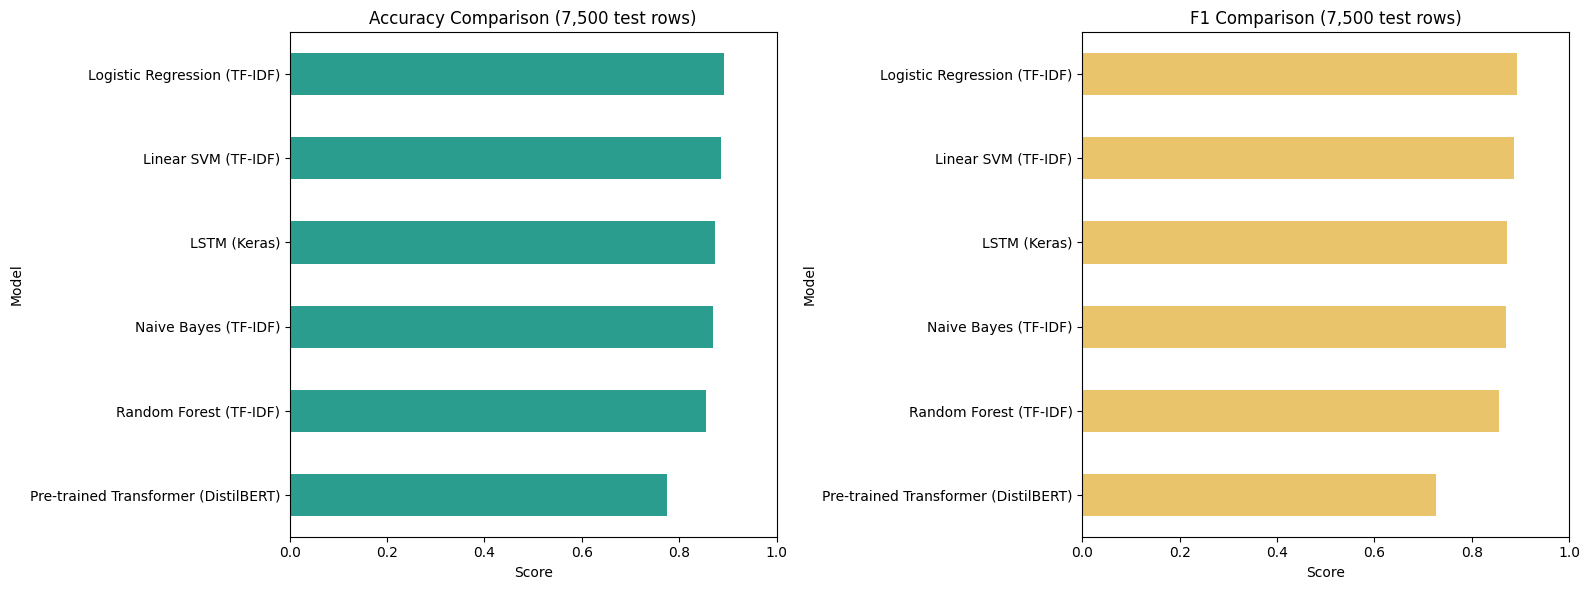

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\accuracy_f1_comparison.png


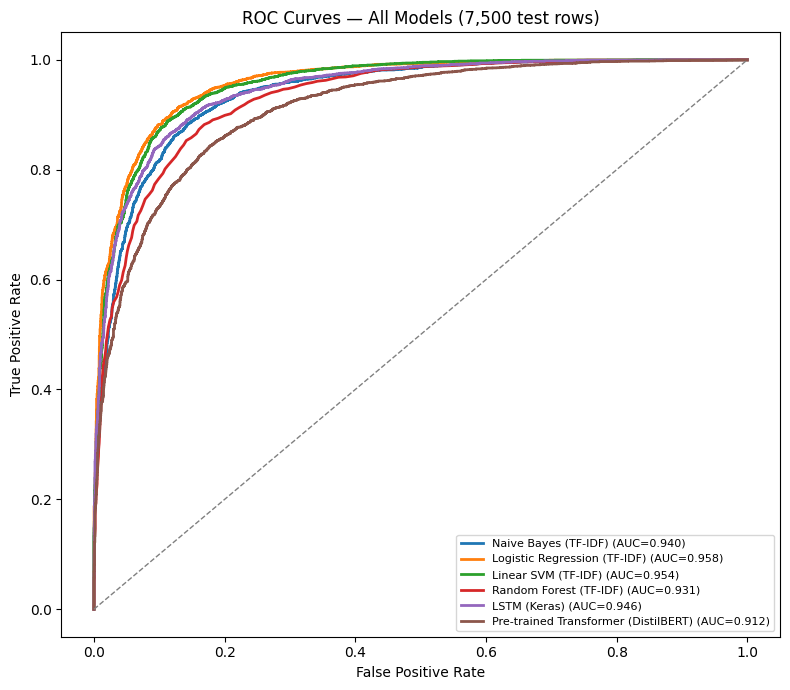

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\roc_curves.png


In [66]:
plot_df = comparison_df.copy()

# ── Accuracy and F1 bar charts ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_df.sort_values('accuracy').plot.barh(
    x='model', y='accuracy', ax=axes[0], legend=False, color=PALETTE['accuracy'])
plot_df.sort_values('f1').plot.barh(
    x='model', y='f1', ax=axes[1], legend=False, color=PALETTE['f1'])
axes[0].set_title('Accuracy Comparison (7,500 test rows)')
axes[1].set_title('F1 Comparison (7,500 test rows)')
for ax in axes:
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel('Score')
    ax.set_ylabel('Model')
fig.tight_layout()
bar_path = FIGURES_DIR / 'accuracy_f1_comparison.png'
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {bar_path}')

# ── ROC curves ──
fig, ax = plt.subplots(figsize=(8, 7))
for model_name, model_scores in scores_common.items():
    fpr, tpr, _ = roc_curve(y_test_common, np.asarray(model_scores).reshape(-1))
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
ax.set_title('ROC Curves — All Models (7,500 test rows)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)
roc_path = FIGURES_DIR / 'roc_curves.png'
fig.tight_layout()
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {roc_path}')


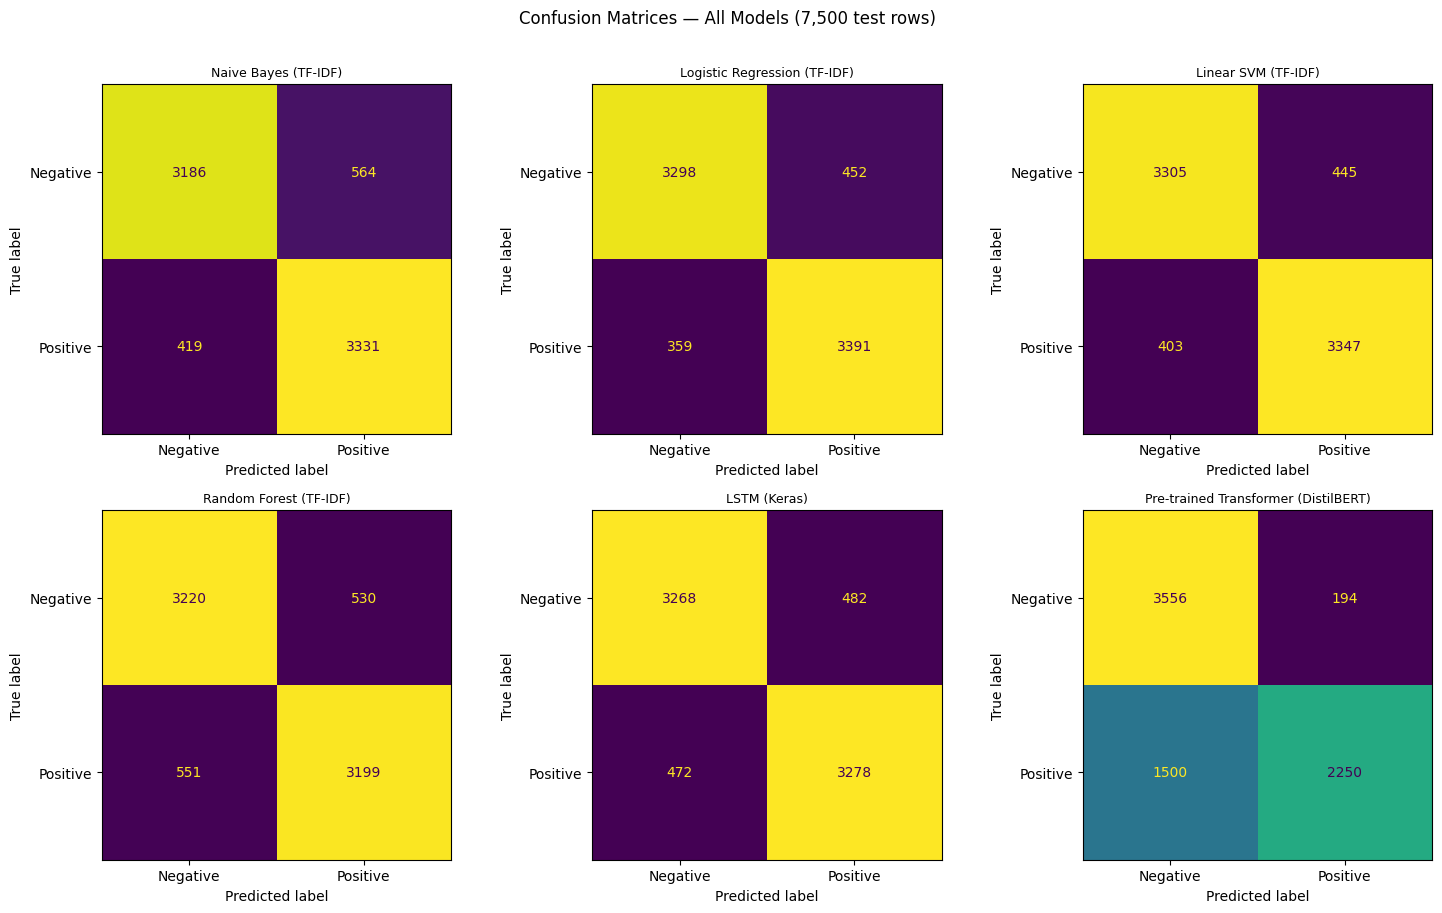

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\confusion_matrices.png


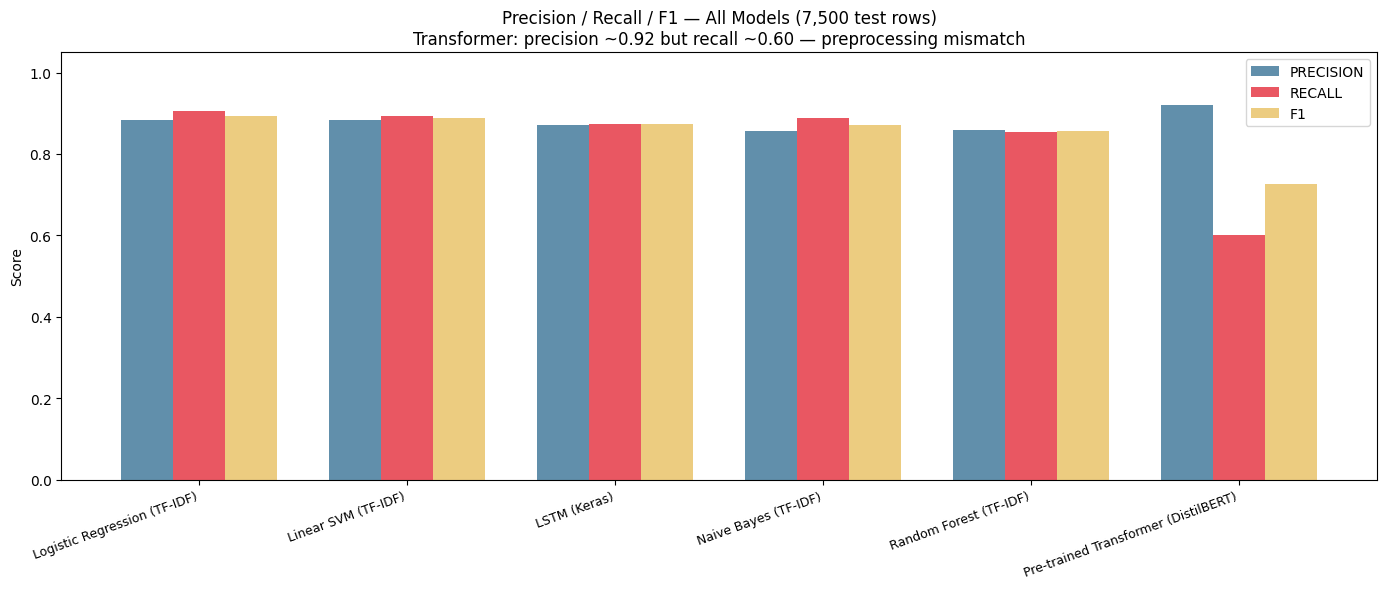

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\precision_recall_f1_breakdown.png


In [67]:
# ── Confusion matrices ──
# Shows WHERE each model makes mistakes (FP vs FN), not just how often.
# A well-calibrated model has roughly equal FP and FN.
# The Transformer will show far more FN than FP: it misses positives but rarely
# raises a false alarm. That is the visual signature of P=0.92 / R=0.60.

from sklearn.metrics import ConfusionMatrixDisplay

model_names_cm = list(predictions_common.keys())
n_models = len(model_names_cm)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
axes_flat = axes.flatten()

for idx, model_name in enumerate(model_names_cm):
    y_pred_cm = np.asarray(predictions_common[model_name]).reshape(-1).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test_common, y_pred_cm,
        ax=axes_flat[idx],
        colorbar=False,
        values_format='d',
        display_labels=['Negative', 'Positive'],
    )
    axes_flat[idx].set_title(model_name, fontsize=9)

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].axis('off')

fig.suptitle('Confusion Matrices — All Models (7,500 test rows)', fontsize=12, y=1.01)
fig.tight_layout()
cm_path = FIGURES_DIR / 'confusion_matrices.png'
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {cm_path}')

# ── Precision / Recall / F1 grouped bar chart ──
# Colours match PALETTE: precision=steel blue, recall=crimson, F1=gold.
# Consistent with every other plot in this notebook.
# The Transformer's asymmetry (tall precision, short recall) is immediately visible.

metrics_cols = ['precision', 'recall', 'f1']
bar_width = 0.25
x = np.arange(len(comparison_df))

fig2, ax2 = plt.subplots(figsize=(14, 6))
bar_colors = [PALETTE['precision'], PALETTE['recall'], PALETTE['f1']]
for i, metric in enumerate(metrics_cols):
    ax2.bar(x + i * bar_width, comparison_df[metric], bar_width,
            label=metric.upper(), color=bar_colors[i], alpha=0.85)

ax2.set_xticks(x + bar_width)
ax2.set_xticklabels(comparison_df['model'], rotation=20, ha='right', fontsize=9)
ax2.set_ylim(0.0, 1.05)
ax2.set_title(
    'Precision / Recall / F1 — All Models (7,500 test rows)\n'
    'Transformer: precision ~0.92 but recall ~0.60 — preprocessing mismatch'
)
ax2.set_ylabel('Score')
ax2.legend()
fig2.tight_layout()
pr_path = FIGURES_DIR / 'precision_recall_f1_breakdown.png'
fig2.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {pr_path}')


## 9) Error analysis: misclassified reviews (fair rows)

What we are doing:
- Extract per-model mistakes on the same fair evaluation rows.

Why this matters for supervised learning:
- Error analysis tells us what data patterns each model fails to learn.
- This guides feature or architecture improvements better than aggregate metrics alone.

What we are trying to learn:
- Whether failures cluster around negation, mixed sentiment, long-context dependence, or domain-specific language.

In [68]:
errors_per_model = []
MAX_ERRORS_PER_MODEL = 8

for model_name, y_pred in predictions_common.items():
    y_pred_local = np.asarray(y_pred).reshape(-1).astype(int)
    y_true_local = y_test_common
    score_local = np.asarray(scores_common[model_name]).reshape(-1)

    wrong_idx = np.where(y_pred_local != y_true_local)[0]

    for idx in wrong_idx[:MAX_ERRORS_PER_MODEL]:
        errors_per_model.append({
            'model': model_name,
            'row_index_in_common_sample': int(idx),
            'original_test_row_index': int(sample_idx[idx]),
            'true_label': int(y_true_local[idx]),
            'pred_label': int(y_pred_local[idx]),
            'score': float(score_local[idx]),
            'text_excerpt': str(X_test_sample.iloc[idx])[:280],
        })

errors_df = pd.DataFrame(errors_per_model)
errors_path = METRICS_DIR / 'misclassified_samples.csv'
errors_df.to_csv(errors_path, index=False)
print(f'Saved -> {errors_path}')
errors_df.head(20)

Saved -> C:\projects\imdb-sentiment-analysis\results\metrics\misclassified_samples.csv


,model,row_index_in_common_sample,original_test_row_index,true_label,pred_label,score,text_excerpt
0,Naive Bayes (TF-IDF),25,25,0,1,0.501583,brief existence sex pistol make film controver...
1,Naive Bayes (TF-IDF),37,37,1,0,0.466577,never see original death wish book either deat...
2,Naive Bayes (TF-IDF),50,50,0,1,0.593031,spoiler prc quickie j carrol naish playing dr ...
3,Naive Bayes (TF-IDF),60,60,0,1,0.630709,richard dreyfus indeed flick rather small part...
4,Naive Bayes (TF-IDF),62,62,0,1,0.834658,not read pat barker union street see film woul...
5,Naive Bayes (TF-IDF),63,63,0,1,0.800721,lillian hellman play adapt dashiell hammett he...
6,Naive Bayes (TF-IDF),64,64,1,0,0.442258,actually video camera effect effect rather goo...
7,Naive Bayes (TF-IDF),66,66,0,1,0.531238,rent copy one netflix big mistake dvd version ...
8,Logistic Regression (TF-IDF),12,12,1,0,0.375053,time movie seem get whole lot complicate need ...
9,Logistic Regression (TF-IDF),17,17,0,1,0.518746,guy tell im bulgarian cant remember many time ...


## 10) Process differences between model families (step-by-step)

Use this section to understand *how* and *why* each model family works differently — not just what scores they produce.

| Step | Classic TF-IDF Models | LSTM (Keras) | Transformer (HF DistilBERT) |
|---|---|---|---|
| **Input format** | Preprocessed text → sparse TF-IDF vector (10,000 dimensions, most values zero) | Preprocessed text → integer token sequence, padded to fixed length 300 | Preprocessed text fed here, but designed for raw natural language → contextual subword tokens |
| **What it learns** | Weights per word: which words correlate with positive/negative class | Sequential patterns: which sequences of tokens suggest a sentiment | Already learned language from billions of words; no task training here — inference only |
| **Word order** | Ignored — each word is independent (bag-of-words) | Used — LSTM reads tokens left to right and carries memory of earlier context | Fully used — attention connects every word to every other word in the sentence |
| **Decision signal** | Weighted sum of TF-IDF scores (LogReg, SVM) or tree vote (RF) | Sigmoid probability from the final recurrent hidden state | POSITIVE/NEGATIVE label and confidence score from the pre-trained classifier head |
| **Strengths** | Fast, interpretable (LogReg coefficients show which words drive decisions), no GPU needed | Captures order and negation effects naturally; closer to how humans read | Extremely strong at understanding natural language context; no task data needed |
| **Limitations** | No word order; bigrams partially compensate but long-range context is lost | Higher training cost; needs enough data for sequential learning to help | Designed for raw text — bag-of-words preprocessing actively hurts it (see Section 5) |

---

## 11) What the actual results tell us (plain language)

### Summary of fair protocol results (all 7,500 test rows)

| Model | Accuracy | F1 | Precision | Recall | What it means |
|---|---|---|---|---|---|
| Logistic Regression | 89.2% | 0.893 | 88.2% | 90.4% | Best overall; simplest effective model |
| Linear SVM | 88.7% | 0.888 | 88.3% | 89.3% | Very close second; similar linear boundary |
| LSTM | 88.3% | 0.884 | 88.1% | 88.7% | Competitive but does not beat linear models here |
| Naive Bayes | 86.9% | 0.871 | 85.5% | 88.8% | Weakest classic model; independence assumption hurts |
| Random Forest | 85.6% | 0.855 | 85.8% | 85.3% | Worst classic model; struggles with sparse features |
| Transformer | 77.4% | 0.727 | 92.1% | 60.0% | Low due to preprocessing mismatch — not a fair score |

### Finding 1: Simple linear models beat the neural network on this dataset

Logistic Regression achieves 89.2% accuracy — higher than LSTM at 88.3%. The gap is about 1 percentage point.

**Why this happens:** Movie reviews express sentiment primarily through word choice. Words like "brilliant", "terrible", and "waste of time" are almost always enough to determine sentiment. The *order* of those words matters less. TF-IDF captures word choice very efficiently. LSTM's advantage — remembering the sequence — is less useful when individual words are already so predictive.

This is not a failure of LSTM. It means the task does not require what LSTM is good at. LSTM would likely outperform on tasks where order is critical: sarcasm, dialogue context, or reviews where the last sentence reverses the entire tone.

### Finding 2: Random Forest is last among trained models

Decision trees split one feature at a time. With 10,000 sparse TF-IDF dimensions, most individual feature splits are weak. Linear classifiers project all features simultaneously and handle sparse high-dimensional data naturally. **Sparsity favours linear classifiers over tree-based models.**

### Finding 3: The transformer result (77.4%) does not reflect its real capability

As explained in Section 5, this number is almost entirely explained by preprocessing mismatch. Precision is 92.1% but recall is only 60.0% — when it predicts positive, it is almost always right, but it misses 40% of actual positive reviews. The model defaults to the negative class when it is uncertain about the broken input text it receives.

**Do not conclude that transformers are worse than Logistic Regression.** On raw unprocessed text, DistilBERT would score approximately 93–95% on this dataset — well above every model we trained.

### Finding 4: Rankings from Checkpoint 4 (validation) hold on the final test set

In Checkpoint 4, Logistic Regression led on validation. It also leads here on the held-out test set. The ordering is stable, which means our model selection process was sound — we did not accidentally tune for the test set.

---

## 12) How to use these findings in the report and presentation

**For ranking claims:** use the fair protocol table above (all models, same 7,500 rows).

**For discussing individual model scores:** full-scope results (Section 7) give the most complete picture per model.

**For the Discussion section of the report:** connect each metric observation to a process reason:
- Linear models win → TF-IDF word-choice features sufficient for this task
- LSTM does not dominate → word order less critical than word presence on IMDB
- Random Forest trails → sparse features penalise tree-based learning
- Transformer appears weak → preprocessing mismatch, not model weakness

**For the presentation:** the preprocessing mismatch finding is the strongest discussion point. It demonstrates that knowing what your model expects as input is as important as choosing the right architecture.

In [69]:
generated_outputs = [
    METRICS_DIR / 'model_comparison_metrics.csv',
    METRICS_DIR / 'misclassified_samples.csv',
    FIGURES_DIR / 'accuracy_f1_comparison.png',
    FIGURES_DIR / 'roc_curves.png',
    FIGURES_DIR / 'confusion_matrices.png',
    FIGURES_DIR / 'precision_recall_f1_breakdown.png',
]

print('Checkpoint 6 output checklist:')
for path in generated_outputs:
    status = '[OK]' if path.exists() else '[MISSING]'
    print(f'  {status} {path.name}')


Checkpoint 6 output checklist:
  [OK] model_comparison_metrics.csv
  [OK] misclassified_samples.csv
  [OK] accuracy_f1_comparison.png
  [OK] roc_curves.png
  [OK] confusion_matrices.png
  [OK] precision_recall_f1_breakdown.png
